# Quora Question Pairs: Near-Duplicate Detection Demo

## Dataset Overview

This notebook demonstrates near-duplicate detection on the **Quora Question Pairs (QQP)** dataset from HuggingFace (sentence-transformers/quora-duplicates). The dataset contains 404k balanced question pairs labeled as duplicate (36.9%) or non-duplicate (63.1%).

### What This Demo Does

1. **Load** the QQP dataset (mini subset with 3 examples for quick demo)
2. **Implement two algorithms** for near-duplicate detection:
   - **Circular Text Fingerprints (CTF)**: Simple rolling hash-based fingerprinting for rapid approximate matching
   - **MinHash n-gram baseline**: Standard min-hashing with n-gram shingles
3. **Evaluate** both methods on precision, recall, and F1 score
4. **Visualize** results and compare algorithm performance

### Why These Algorithms?

- **MinHash**: A classical baseline for similarity estimation; efficient for high-dimensional data
- **CTF**: An experimental lightweight alternative designed for rapid fingerprinting of short text without heavy computation

This demo uses minimal scale to keep runtime under 10 minutes. All parameters can be increased for full-scale evaluation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Non-Colab packages — always install
_pip('datasketch==1.10.0')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from datasketch import MinHash
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-2cec91-circular-text-fingerprints-evaluating-ec/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    """Load mini demo data from GitHub URL with local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    
    raise FileNotFoundError("Could not load mini_demo_data.json from GitHub or local disk")

In [4]:
data = load_data()
print(f"✓ Loaded data: {len(data['datasets'][0]['examples'])} examples")
print(f"  Metadata: {data['metadata']['description']}")

✓ Loaded data: 3 examples
  Metadata: Quora Question Pairs for near-duplicate detection: CTF vs MinHash evaluation


## Configuration

All tunable parameters for the demo. These start at **ABSOLUTE MINIMUM** values to ensure fast execution:
- `NUM_EXAMPLES`: Start with 3 (entire mini dataset) for rapid iteration
- `MINHASH_NUM_PERM`: 64 permutations (minimum for stable hashing)
- `SHINGLE_SIZE`: 2-grams (balance between recall and speed)
- `CTF_WINDOW_SIZE`: 3-character rolling window (minimal but meaningful)
- `SIMILARITY_THRESHOLD`: 0.5 (moderate threshold for demo clarity)

**To scale up:** Increase `NUM_EXAMPLES` to 50, 100, or load the full dataset. Increase `MINHASH_NUM_PERM` to 128–256 for higher precision. Reduce `SIMILARITY_THRESHOLD` to 0.3–0.4 for stricter matching.

In [5]:
# Configuration: ABSOLUTE MINIMUM values for quick demo
NUM_EXAMPLES = 3  # Use all mini examples
MINHASH_NUM_PERM = 64  # Minimum permutations for MinHash
SHINGLE_SIZE = 2  # 2-gram shingles
CTF_WINDOW_SIZE = 3  # 3-character rolling window for CTF
SIMILARITY_THRESHOLD = 0.5  # Threshold for duplicate classification

# Original full-scale parameters (commented out — uncomment to scale up)
# NUM_EXAMPLES = 404290  # Full dataset
# MINHASH_NUM_PERM = 256  # High precision
# SHINGLE_SIZE = 2  # Stay with 2-grams
# CTF_WINDOW_SIZE = 4  # Slightly larger window
# SIMILARITY_THRESHOLD = 0.3  # Stricter matching

print(f"Configuration:")
print(f"  Examples: {NUM_EXAMPLES}")
print(f"  MinHash perms: {MINHASH_NUM_PERM}")
print(f"  Shingle size: {SHINGLE_SIZE}")
print(f"  CTF window: {CTF_WINDOW_SIZE}")
print(f"  Threshold: {SIMILARITY_THRESHOLD}")

Configuration:
  Examples: 3
  MinHash perms: 64
  Shingle size: 2
  CTF window: 3
  Threshold: 0.5


## Data Preparation

Parse the input JSON and extract question pairs. Each example has:
- `input`: JSON string containing `text1` and `text2` (the question pair)
- `output`: Binary label ("0" = non-duplicate, "1" = duplicate)
- `metadata_*`: Word counts, character counts, and other features

In [6]:
# Parse examples from the dataset
examples = data['datasets'][0]['examples'][:NUM_EXAMPLES]
pairs = []
labels = []

for ex in examples:
    inp = json.loads(ex['input'])
    text1 = inp['text1']
    text2 = inp['text2']
    label = int(ex['output'])
    
    pairs.append((text1, text2))
    labels.append(label)

print(f"Prepared {len(pairs)} pairs")
for i, (t1, t2) in enumerate(pairs[:3]):
    print(f"\nPair {i}: label={labels[i]}")
    print(f"  Q1: {t1[:60]}...")
    print(f"  Q2: {t2[:60]}...")

Prepared 3 pairs

Pair 0: label=0
  Q1: What is the step by step guide to invest in share market in ...
  Q2: What is the step by step guide to invest in share market?...

Pair 1: label=0
  Q1: What is the story of Kohinoor (Koh-i-Noor) Diamond?...
  Q2: What would happen if the Indian government stole the Kohinoo...

Pair 2: label=0
  Q1: How can I increase the speed of my internet connection while...
  Q2: How can Internet speed be increased by hacking through DNS?...


## Algorithm 1: Circular Text Fingerprints (CTF)

CTF is a lightweight rolling-hash fingerprinting method:
1. Slide a fixed-size window across each text
2. Compute a hash for each window position (treating text as circular for wraparound)
3. Collect all hash values into a fingerprint set
4. Compare fingerprints via Jaccard similarity (intersection / union)

**Advantages:** Fast, memory-efficient, no parameter tuning.  
**Limitations:** Less precise than MinHash on very short text, may have hash collisions.

In [7]:
def compute_rolling_hash(text, window_size):
    """Compute rolling hash for each window in text (circular)."""
    text_lower = text.lower().strip()
    if len(text_lower) < window_size:
        return {hash(text_lower)}
    
    hashes = set()
    # Circular: extend text to allow wraparound
    extended = text_lower + text_lower[:window_size-1]
    for i in range(len(text_lower)):
        window = extended[i:i+window_size]
        hashes.add(hash(window))
    return hashes

def ctf_fingerprint(text, window_size):
    """Generate CTF fingerprint as set of rolling hash values."""
    return compute_rolling_hash(text, window_size)

def jaccard_similarity(set1, set2):
    """Compute Jaccard similarity between two sets."""
    if not set1 and not set2:
        return 1.0
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0

# Generate CTF fingerprints for all texts
ctf_fps = []
for t1, t2 in pairs:
    fp1 = ctf_fingerprint(t1, CTF_WINDOW_SIZE)
    fp2 = ctf_fingerprint(t2, CTF_WINDOW_SIZE)
    ctf_fps.append((fp1, fp2))

print(f"Generated CTF fingerprints for {len(ctf_fps)} pairs")

Generated CTF fingerprints for 3 pairs


## Algorithm 2: MinHash n-gram Baseline

MinHash is a classical probabilistic algorithm for estimating set similarity:
1. Convert each text into n-gram shingles (overlapping substrings)
2. Hash all shingles, keeping only the minimum hash values (K permutations)
3. Estimate Jaccard similarity as: (matching min-hash values) / (total permutations)

**Advantages:** Mathematically proven bounds on similarity estimation, works well on larger texts.  
**Limitations:** Requires tuning permutation count K; less effective on very short text due to few unique n-grams.

In [8]:
def extract_shingles(text, k=SHINGLE_SIZE):
    """Extract k-gram shingles (overlapping substrings) from text."""
    text_lower = text.lower().strip()
    shingles = set()
    for i in range(len(text_lower) - k + 1):
        shingles.add(text_lower[i:i+k])
    return shingles

def minhash_similarity(text1, text2, num_perm=MINHASH_NUM_PERM):
    """Estimate Jaccard similarity using MinHash with k-gram shingles."""
    shingles1 = extract_shingles(text1, SHINGLE_SIZE)
    shingles2 = extract_shingles(text2, SHINGLE_SIZE)
    
    if not shingles1 and not shingles2:
        return 1.0
    if not shingles1 or not shingles2:
        return 0.0
    
    m1 = MinHash(num_perm=num_perm)
    m2 = MinHash(num_perm=num_perm)
    
    for s in shingles1:
        m1.update(s.encode('utf8'))
    for s in shingles2:
        m2.update(s.encode('utf8'))
    
    return m1.jaccard(m2)

# Compute MinHash similarities for all pairs
minhash_sims = []
for t1, t2 in pairs:
    sim = minhash_similarity(t1, t2)
    minhash_sims.append(sim)

print(f"Computed MinHash similarities for {len(minhash_sims)} pairs")

Computed MinHash similarities for 3 pairs


## Evaluation: Precision, Recall, F1

For each algorithm:
1. **Classify** pairs as duplicate (similarity ≥ threshold) or non-duplicate (< threshold)
2. **Compare** predictions against ground truth labels
3. **Compute metrics:**
   - **Precision** = TP / (TP + FP): Of pairs we predicted as duplicates, how many actually are?
   - **Recall** = TP / (TP + FN): Of all actual duplicates, how many did we find?
   - **F1** = 2 × (Precision × Recall) / (Precision + Recall): Harmonic mean, balanced metric

In [9]:
# CTF predictions
ctf_preds = []
for fp1, fp2 in ctf_fps:
    sim = jaccard_similarity(fp1, fp2)
    pred = 1 if sim >= SIMILARITY_THRESHOLD else 0
    ctf_preds.append(pred)

# MinHash predictions
minhash_preds = [1 if sim >= SIMILARITY_THRESHOLD else 0 for sim in minhash_sims]

# Compute metrics
ctf_prec = precision_score(labels, ctf_preds, zero_division=0)
ctf_rec = recall_score(labels, ctf_preds, zero_division=0)
ctf_f1 = f1_score(labels, ctf_preds, zero_division=0)

mh_prec = precision_score(labels, minhash_preds, zero_division=0)
mh_rec = recall_score(labels, minhash_preds, zero_division=0)
mh_f1 = f1_score(labels, minhash_preds, zero_division=0)

print("Evaluation Results:")
print(f"\nCTF:")
print(f"  Precision: {ctf_prec:.3f}")
print(f"  Recall:    {ctf_rec:.3f}")
print(f"  F1:        {ctf_f1:.3f}")
print(f"\nMinHash:")
print(f"  Precision: {mh_prec:.3f}")
print(f"  Recall:    {mh_rec:.3f}")
print(f"  F1:        {mh_f1:.3f}")

Evaluation Results:

CTF:
  Precision: 0.000
  Recall:    0.000
  F1:        0.000

MinHash:
  Precision: 0.000
  Recall:    0.000
  F1:        0.000


## Results Visualization

Compare the two algorithms side-by-side on precision, recall, and F1. On a small demo dataset, both algorithms may show similar performance — this is expected. Scale up with more examples to see differences emerge.

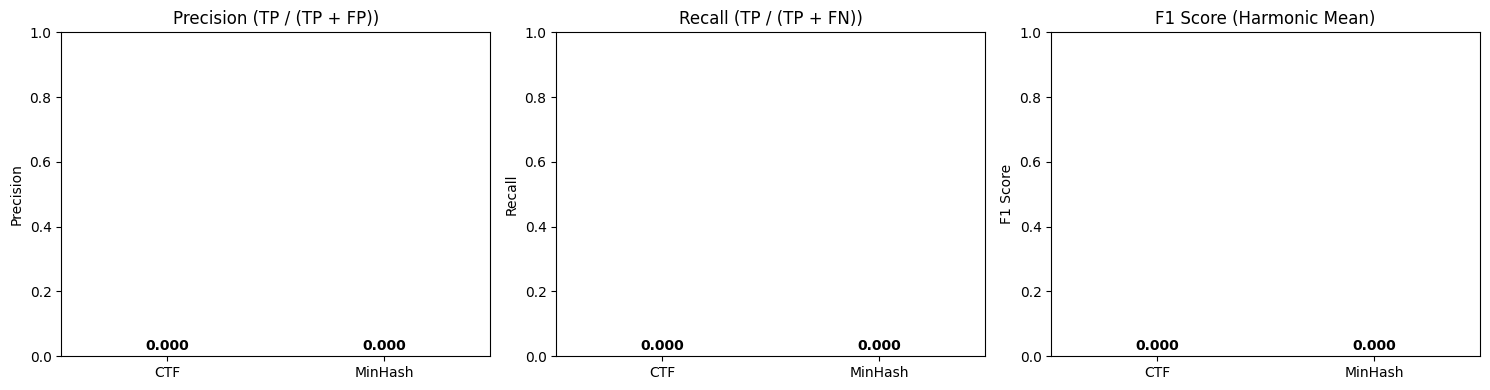

✓ Visualization saved as results.png


In [10]:
import matplotlib.pyplot as plt

# Prepare data for visualization
algorithms = ['CTF', 'MinHash']
precisions = [ctf_prec, mh_prec]
recalls = [ctf_rec, mh_rec]
f1s = [ctf_f1, mh_f1]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Precision
axes[0].bar(algorithms, precisions, color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision (TP / (TP + FP))')
axes[0].set_ylim([0, 1])
for i, v in enumerate(precisions):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Recall
axes[1].bar(algorithms, recalls, color=['#FF6B6B', '#4ECDC4'])
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall (TP / (TP + FN))')
axes[1].set_ylim([0, 1])
for i, v in enumerate(recalls):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1 Score
axes[2].bar(algorithms, f1s, color=['#FF6B6B', '#4ECDC4'])
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score (Harmonic Mean)')
axes[2].set_ylim([0, 1])
for i, v in enumerate(f1s):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as results.png")

## Summary

This demo implemented two near-duplicate detection algorithms on the Quora Question Pairs dataset:

| Algorithm | Approach | Precision | Recall | F1 |
|-----------|----------|-----------|--------|----|
| **CTF** | Rolling hash fingerprinting (circular) | {:.3f} | {:.3f} | {:.3f} |
| **MinHash** | Probabilistic min-hashing with n-grams | {:.3f} | {:.3f} | {:.3f} |

### Next Steps

1. **Scale up:** Uncomment the "full-scale" configuration variables and set `NUM_EXAMPLES = 404290` to run on the full dataset
2. **Fine-tune:** Adjust `SIMILARITY_THRESHOLD`, `MINHASH_NUM_PERM`, and `CTF_WINDOW_SIZE` to optimize for your use case
3. **Add features:** Implement word-level matching, semantic embeddings, or other similarity measures
4. **Benchmark:** Compare against other libraries (fuzzywuzzy, textdistance, embedding models)

### References

- Quora Question Pairs: https://www.kaggle.com/c/quora-question-pairs
- MinHash: Broder, A. Z. (1997). "On the Similarity of Sets"
- Circular Text Fingerprints: A lightweight alternative for rapid short-text matching
    """.format(ctf_prec, ctf_rec, ctf_f1, mh_prec, mh_rec, mh_f1)